# 01 — Meet the connectome

The male *Drosophila* CNS connectome: **165,122 neurons, 124 million synapses**, brain + eyes + ventral nerve cord.
This notebook loads it with `flyhigh` and pokes at it. Read `docs/01-connectome.md` alongside.

Run `uv run python -m flyhigh.data.download` once first (1.1 GB).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, polars as pl
from flyhigh.data.connectome import Connectome
import matplotlib as mpl, matplotlib.pyplot as plt
# dataviz conventions: fixed categorical order, single-hue sequential, thin marks, recessive grid
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.prop_cycle": mpl.cycler(color=C), "lines.linewidth": 2, "font.size": 10})
pl.Config.set_tbl_rows(12)
c = Connectome.load("../data/raw")   # ~8 s the first time, ~1 s from the parquet cache
c.n_neurons, c.n_edges, int(c.edges["syn_count"].sum())

(165122, 25563197, 124025046)

## What is in the table
One row per neuron. `index` is our dense id (used in the edge list), `body_id` is Janelia's id (use it in neuPrint / Neuroglancer).

In [2]:
c.neurons.head(5)

body_id,index,type,instance,class,superclass,region,side,dimorphism,hex1,hex2,nt,nt_sign,nt_confidence
i64,i64,str,str,str,str,str,str,str,f64,f64,str,i8,f64
10001,0,"""DNp01""","""DNp01(GF)_R""",null,"""descending_neuron""","""brain""","""R""",null,null,null,"""acetylcholine""",1,0.500496
10002,1,"""OCG01d""","""OCG01d_L""",null,"""visual_projection""","""optic""","""L""",null,null,null,"""acetylcholine""",1,0.955895
10003,2,"""VCH""","""VCH_R""",null,"""visual_centrifugal""","""optic""","""R""",null,null,null,"""gaba""",-1,0.879325
10005,3,"""AOTU019""","""AOTU019_R""",null,"""cb_intrinsic""","""brain""","""R""",null,null,null,"""gaba""",-1,0.835076
10006,4,"""VS""","""VS_L""",null,"""visual_projection""","""optic""","""L""",null,null,null,"""acetylcholine""",1,0.904134


## Where the neurons live
Two thirds of all neurons are in the optic lobes. `superclass` is the dataset's coarse cell class; `region` is our grouping of it.

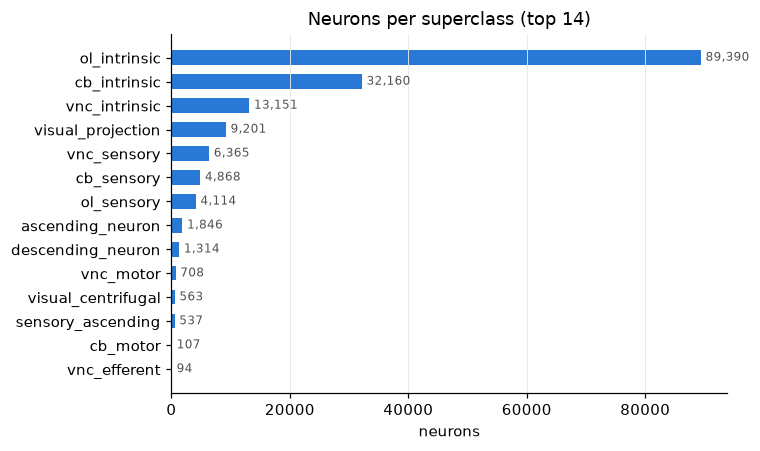

In [3]:
d = c.describe()
by_sc = (pl.DataFrame({"superclass": list(d["by_superclass"]), "n": list(d["by_superclass"].values())})
         .filter(pl.col("superclass").is_not_null()).sort("n", descending=True).head(14))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(by_sc["superclass"][::-1], by_sc["n"][::-1], color=C[0], height=0.6)
for y, n in enumerate(by_sc["n"][::-1]): ax.text(n + 800, y, f"{n:,}", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("neurons"); ax.set_title("Neurons per superclass (top 14)"); ax.grid(axis="y", visible=False)
plt.tight_layout()

## Neurotransmitters → sign of a connection
The dataset predicts each neuron's main transmitter from its synapse images. We map ACh/DA/OA/5-HT → **excitatory (+1)** and GABA/Glu/histamine → **inhibitory (−1)**. About 62 % of neurons are cholinergic.

In [4]:
nt = c.neurons.group_by("nt", "nt_sign").len().sort("len", descending=True)
nt.with_columns((pl.col("len") / c.n_neurons * 100).round(1).alias("%"))

nt,nt_sign,len,%
str,i8,u32,f64
"""acetylcholine""",1,103718,62.8
"""glutamate""",-1,29296,17.7
"""gaba""",-1,22055,13.4
"""histamine""",-1,5910,3.6
"""unclear""",1,3275,2.0
"""dopamine""",1,392,0.2
"""serotonin""",1,345,0.2
"""octopamine""",1,131,0.1


## How connected is a neuron?
Synapse counts per neuron are heavy-tailed: most neurons have a few hundred input synapses, a few have tens of thousands. Log axes are the only way to see this.

mean input synapses per neuron: 751


type,superclass,in,out
str,str,i32,i32
"""APL""","""cb_intrinsic""",119936,102264
"""APL""","""cb_intrinsic""",114090,107649
"""CT1""","""ol_intrinsic""",81318,140897
"""LPi21""","""ol_intrinsic""",76073,50226
"""CT1""","""ol_intrinsic""",73310,112796
"""LPi21""","""ol_intrinsic""",68272,39283
"""Am1""","""ol_intrinsic""",65895,49864
"""Am1""","""ol_intrinsic""",60112,42446


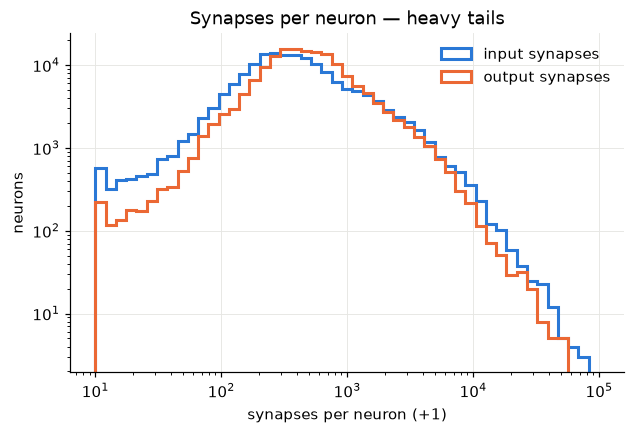

In [5]:
in_syn = c.edges.group_by("post_idx").agg(pl.col("syn_count").sum().alias("in"))
out_syn = c.edges.group_by("pre_idx").agg(pl.col("syn_count").sum().alias("out"))
deg = c.neurons.join(in_syn, left_on="index", right_on="post_idx", how="left").join(out_syn, left_on="index", right_on="pre_idx", how="left").fill_null(0)
fig, ax = plt.subplots(figsize=(6.5, 4))
bins = np.logspace(1, 5, 50)   # neurons with < 10 synapses are fragments; hide the integer spikes
for col, color, label in (("in", C[0], "input synapses"), ("out", C[1], "output synapses")):
    ax.hist(deg[col].to_numpy() + 1, bins=bins, histtype="step", linewidth=2, color=color, label=label)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("synapses per neuron (+1)"); ax.set_ylabel("neurons")
ax.legend(frameon=False); ax.set_title("Synapses per neuron — heavy tails")
print("mean input synapses per neuron:", round(deg["in"].mean()))
deg.sort("in", descending=True).select("type", "superclass", "in", "out").head(8)

## Famous neurons
Cell types are shared with FlyWire / the hemibrain, so decades of physiology map onto these ids. A few we will use:

In [6]:
famous = {"DNp01": "giant fiber — escape take-off", "LC4": "looming detector", "LPLC2": "looming detector",
          "HSN": "horizontal-motion tangential cell", "T4a": "motion detector (front→back)", "R1-R6": "photoreceptors",
          "DNa02": "steering descending neuron", "LB3b": "sugar taste neuron (Gr64f)", "MN9": "proboscis motor neuron",
          "APL": "the one inhibitory neuron that keeps memory sparse", "KCg-m": "Kenyon cell (memory)"}
rows = [(t, len(c.ids_by_type(rf"^{t}$")), c.neurons.filter(pl.col("type") == t)["nt"][0], what) for t, what in famous.items()]
pl.DataFrame(rows, schema=["type", "count", "nt", "what it does"], orient="row")

type,count,nt,what it does
str,i64,str,str
"""DNp01""",2,"""acetylcholine""","""giant fiber — escape take-off"""
"""LC4""",126,"""acetylcholine""","""looming detector"""
"""LPLC2""",185,"""acetylcholine""","""looming detector"""
"""HSN""",2,"""acetylcholine""","""horizontal-motion tangential c…"
"""T4a""",1684,"""acetylcholine""","""motion detector (front→back)"""
"""R1-R6""",1394,"""histamine""","""photoreceptors"""
"""DNa02""",2,"""acetylcholine""","""steering descending neuron"""
"""LB3b""",11,"""acetylcholine""","""sugar taste neuron (Gr64f)"""
"""MN9""",2,"""acetylcholine""","""proboscis motor neuron"""


## Tracing a circuit: looming → giant fiber
The escape reflex: looming-sensitive visual neurons (LC4, LPLC2) synapse **directly** onto the giant fiber (DNp01), which drives the take-off jump. How strong is that connection?

In [7]:
gf = c.ids_by_type(r"^DNp01$")
inputs = (c.edges.filter(pl.col("post_idx").is_in(pl.Series(gf).implode()))
          .join(c.neurons.select(pl.col("index").alias("pre_idx"), "type", "nt", "side"), on="pre_idx")
          .group_by("type", "nt").agg(pl.col("syn_count").sum().alias("synapses"), pl.len().alias("cells"))
          .sort("synapses", descending=True))
inputs.head(12)

type,nt,synapses,cells
str,str,i32,u32
"""LC4""","""acetylcholine""",6362,126
"""LPLC2""","""acetylcholine""",4862,185
"""DNp70""","""acetylcholine""",1416,4
"""PVLP122""","""acetylcholine""",1216,11
"""SAD064""","""acetylcholine""",1215,6
"""SAD073""","""gaba""",1177,8
"""PVLP010""","""glutamate""",711,2
"""PVLP123""","""acetylcholine""",620,16
"""PVLP151""","""acetylcholine""",603,8


## Sex-specific circuitry
This is a *male* connectome, and the annotation marks neurons that are male-specific or differ from the female (the headline finding of the Cell paper). Where are they?

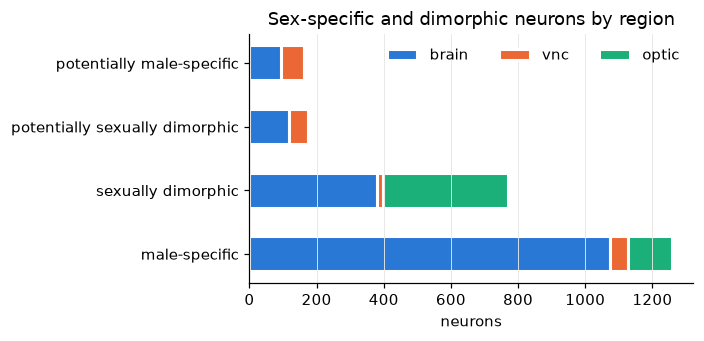

In [8]:
dim = (c.neurons.filter(pl.col("dimorphism").is_not_null())
       .group_by("dimorphism", "region").len().sort("len", descending=True))
piv = dim.pivot(on="region", index="dimorphism", values="len").fill_null(0)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
regions = [r for r in ("brain", "vnc", "optic") if r in piv.columns]
left = np.zeros(piv.height)
for i, r in enumerate(regions):
    vals = piv[r].to_numpy(); ax.barh(piv["dimorphism"], vals, left=left, color=C[i], label=r, height=0.55, edgecolor="white", linewidth=2); left += vals
ax.legend(frameon=False, ncol=3); ax.grid(axis="y", visible=False); ax.set_xlabel("neurons"); ax.set_title("Sex-specific and dimorphic neurons by region")
plt.tight_layout()

## The eye has coordinates
The lamina/medulla columnar neurons (L1, L2, L5, Tm1, …) carry hexagonal eye-column coordinates (`hex1`, `hex2`): one L1 per ommatidium, ≈ 880 columns per eye. That is our map from camera pixels to the visual system in milestone 2.

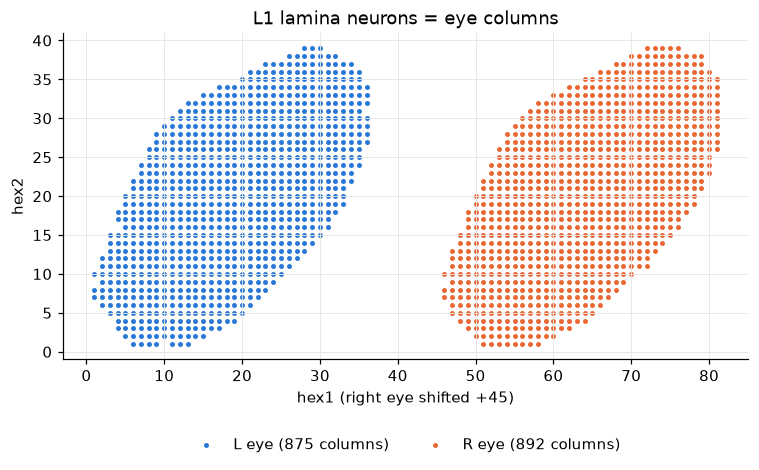

In [9]:
eye = c.neurons.filter((pl.col("type") == "L1") & pl.col("hex1").is_not_null())
fig, ax = plt.subplots(figsize=(7, 4))
for i, side in enumerate(("L", "R")):
    g = eye.filter(pl.col("side") == side)
    ax.scatter(g["hex1"] + (0 if side == "L" else 45), g["hex2"], s=5, color=C[i], label=f"{side} eye ({g.height} columns)")
ax.set_aspect("equal"); ax.set_xlabel("hex1 (right eye shifted +45)"); ax.set_ylabel("hex2"); ax.set_title("L1 lamina neurons = eye columns")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()

## Try it
- `c.ids_by_type(r"^DNa")` — all the DNa steering neurons.
- `c.subgraph(region="brain")` — the central brain only (38,546 neurons).
- Change `gf` above to `c.ids_by_type(r"^MN9$")` to see who talks to the feeding motor neuron.